# CyberShield Threat Hunter â€” RL Training Notebook

Train 4 RL algorithms (DQN, REINFORCE, PPO, A2C) on the Cyber Threat Hunting environment.
Each algorithm runs 12 hyperparameter configurations.

**Instructions:**
1. Upload the `environment/` and `training/` folders to Colab
2. Run all cells
3. Download the `models/` and `results/` folders when done

## 1. Setup

In [ ]:
# Install dependencies
!pip install -q gymnasium>=0.29.0 stable-baselines3>=2.3.0 torch matplotlib tensorboard pandas

In [ ]:
# Mount Google Drive to save models persistently
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Option A: Clone from GitHub (if you've pushed the repo)
# !git clone https://github.com/YOUR_USERNAME/YOUR_NAME_rl_summative.git
# %cd YOUR_NAME_rl_summative

# Option B: Upload files manually
# Use the file browser on the left to upload:
#   environment/__init__.py
#   environment/custom_env.py
#   environment/network_graph.py
#   environment/rendering.py
#   training/__init__.py
#   training/dqn_training.py
#   training/pg_training.py
#   training/reinforce_training.py

# Option C: Upload as zip
# from google.colab import files
# uploaded = files.upload()  # upload rl_summative.zip
# !unzip -o rl_summative.zip

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import csv
import torch

# Ensure project root is in path
PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from environment.custom_env import CyberThreatHuntEnv
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback

# Create output directories
for d in ['models/dqn', 'models/pg/ppo', 'models/pg/a2c', 'models/pg/reinforce', 'results']:
    os.makedirs(d, exist_ok=True)

print(f'PyTorch device: {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'Project root: {PROJECT_ROOT}')

PyTorch device: cuda
Project root: /content


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Verify environment works
env = CyberThreatHuntEnv(num_nodes=14, num_threats=4, max_steps=100)
obs, info = env.reset(seed=42)
print(f'Observation shape: {obs.shape}')
print(f'Action space: {env.action_space}')
print(f'Initial info: {info}')

# Quick random rollout
total_r = 0
for _ in range(100):
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    total_r += r
    if term or trunc:
        break
print(f'Random agent reward: {total_r:.1f}, outcome: {info.get("outcome", "running")}')
env.close()

Observation shape: (89,)
Action space: Discrete(6)
Initial info: {'agent_position': 0, 'step': 0, 'total_damage': 0.0, 'threats_neutralized': 0, 'total_threats': 4, 'discovered_threats': 0}
Random agent reward: -25.0, outcome: critical_breach


## 2. Helper Functions

In [ ]:
from training.callbacks import TrainingMetricsCallback
from stable_baselines3.common.callbacks import CallbackList

def make_env(seed=None):
    def _init():
        env = CyberThreatHuntEnv(num_nodes=14, num_threats=4, max_steps=100)
        env.reset(seed=seed)
        return env
    return _init


def train_sb3_model(algo_cls, algo_name, exp, total_timesteps=50000, seed=42):
    """Generic training function for SB3 algorithms with metrics logging."""
    print(f"\n{'='*60}")
    print(f"{algo_name.upper()} Experiment: {exp['name']}")
    print(f"{'='*60}")

    env = DummyVecEnv([make_env(seed=seed)])
    eval_env = DummyVecEnv([make_env(seed=seed + 100)])

    if algo_name == 'dqn':
        model_dir = f'models/dqn/{exp["name"]}'
        log_dir = f'results/dqn/{exp["name"]}'
    else:
        model_dir = f'models/pg/{algo_name}/{exp["name"]}'
        log_dir = f'results/{algo_name}/{exp["name"]}'

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=log_dir,
        eval_freq=5000,
        n_eval_episodes=10,
        deterministic=True,
        verbose=0,
    )

    metrics_callback = TrainingMetricsCallback(log_path=log_dir)
    callback = CallbackList([eval_callback, metrics_callback])

    model_kwargs = {
        'policy': 'MlpPolicy',
        'env': env,
        'learning_rate': exp['lr'],
        'gamma': exp['gamma'],
        'policy_kwargs': {'net_arch': exp['net_arch']},
        'tensorboard_log': 'results/tensorboard',
        'verbose': 0,
        'seed': seed,
    }

    if algo_name == 'dqn':
        model_kwargs.update({
            'batch_size': exp['batch_size'],
            'buffer_size': exp['buffer_size'],
            'exploration_initial_eps': exp['eps_start'],
            'exploration_final_eps': exp['eps_end'],
            'exploration_fraction': exp['eps_fraction'],
        })
    elif algo_name == 'ppo':
        model_kwargs.update({
            'n_steps': exp['n_steps'],
            'batch_size': exp['batch_size'],
            'n_epochs': exp['n_epochs'],
            'clip_range': exp['clip_range'],
            'ent_coef': exp['ent_coef'],
            'vf_coef': exp['vf_coef'],
        })
    elif algo_name == 'a2c':
        model_kwargs.update({
            'n_steps': exp['n_steps'],
            'ent_coef': exp['ent_coef'],
            'vf_coef': exp['vf_coef'],
        })

    model = algo_cls(**model_kwargs)

    start = time.time()
    model.learn(total_timesteps=total_timesteps, callback=callback,
                tb_log_name=f"{algo_name}_{exp['name']}")
    train_time = time.time() - start

    model.save(os.path.join(model_dir, 'final_model'))

    mean_reward, std_reward = evaluate_policy(
        model, eval_env, n_eval_episodes=20, deterministic=True
    )
    print(f'  Result: {mean_reward:.2f} +/- {std_reward:.2f} ({train_time:.1f}s)')

    env.close()
    eval_env.close()

    result = {k: v for k, v in exp.items()}
    result.update({
        'algorithm': algo_name.upper(),
        'mean_reward': mean_reward,
        'std_reward': std_reward,
        'training_time_s': train_time,
        'net_arch': str(exp['net_arch']),
    })
    return result


## 3. Train DQN (12 experiments)

In [ ]:
DQN_EXPERIMENTS = [
    {"name": "dqn_baseline", "lr": 1e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_high_lr", "lr": 5e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_low_lr", "lr": 1e-5, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_low_gamma", "lr": 1e-4, "gamma": 0.9, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_high_gamma", "lr": 1e-4, "gamma": 0.999, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_small_batch", "lr": 1e-4, "gamma": 0.99, "batch_size": 32,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_large_batch", "lr": 1e-4, "gamma": 0.99, "batch_size": 128,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_small_buffer", "lr": 1e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 10000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [128, 128]},
    {"name": "dqn_slow_explore", "lr": 1e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.01, "eps_fraction": 0.5,
     "net_arch": [128, 128]},
    {"name": "dqn_fast_explore", "lr": 1e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.1, "eps_fraction": 0.1,
     "net_arch": [128, 128]},
    {"name": "dqn_deep_net", "lr": 1e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [256, 256, 128]},
    {"name": "dqn_wide_net", "lr": 1e-4, "gamma": 0.99, "batch_size": 64,
     "buffer_size": 50000, "eps_start": 1.0, "eps_end": 0.05, "eps_fraction": 0.3,
     "net_arch": [512, 256]},
]

TIMESTEPS = 50000  # Increase to 100000+ for better results if time allows

dqn_results = []
for exp in DQN_EXPERIMENTS:
    result = train_sb3_model(DQN, 'dqn', exp, total_timesteps=TIMESTEPS)
    dqn_results.append(result)

dqn_df = pd.DataFrame(dqn_results)
dqn_df.to_csv('results/dqn_results.csv', index=False)
print(f"\n{'='*60}")
print("DQN RESULTS SUMMARY")
print(f"{'='*60}")
print(dqn_df[['name', 'mean_reward', 'std_reward', 'training_time_s']].to_string(index=False))


DQN Experiment: dqn_baseline


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Result: 7.42 +/- 22.84 (74.9s)

DQN Experiment: dqn_high_lr
  Result: -4.00 +/- 19.57 (73.0s)

DQN Experiment: dqn_low_lr
  Result: -13.50 +/- 2.39 (73.0s)

DQN Experiment: dqn_low_gamma
  Result: -3.50 +/- 18.68 (73.0s)

DQN Experiment: dqn_high_gamma
  Result: 9.30 +/- 24.57 (73.2s)

DQN Experiment: dqn_small_batch
  Result: 1.90 +/- 21.25 (72.9s)

DQN Experiment: dqn_large_batch
  Result: 4.60 +/- 24.95 (73.7s)

DQN Experiment: dqn_small_buffer
  Result: 11.97 +/- 23.54 (73.1s)

DQN Experiment: dqn_slow_explore
  Result: 2.38 +/- 19.66 (71.9s)

DQN Experiment: dqn_fast_explore
  Result: 8.20 +/- 18.07 (74.2s)

DQN Experiment: dqn_deep_net
  Result: 7.28 +/- 22.55 (79.7s)

DQN Experiment: dqn_wide_net
  Result: 6.20 +/- 18.48 (73.3s)

DQN RESULTS SUMMARY
            name  mean_reward  std_reward  training_time_s
    dqn_baseline        7.425   22.843640        74.918377
     dqn_high_lr       -4.000   19.570386        72.975353
      dqn_low_lr      -13.500    2.392697        73.00

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Train PPO (12 experiments)

In [ ]:
PPO_EXPERIMENTS = [
    {"name": "ppo_baseline", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_high_lr", "lr": 1e-3, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_low_lr", "lr": 1e-5, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_low_gamma", "lr": 3e-4, "gamma": 0.9, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_wide_clip", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.3, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_narrow_clip", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.1, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_high_entropy", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.05,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_no_entropy", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.0,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_long_rollout", "lr": 3e-4, "gamma": 0.99, "n_steps": 512,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_deep_net", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [256, 256, 128]},
    {"name": "ppo_few_epochs", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 64, "n_epochs": 3, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "ppo_large_batch", "lr": 3e-4, "gamma": 0.99, "n_steps": 256,
     "batch_size": 128, "n_epochs": 10, "clip_range": 0.2, "ent_coef": 0.01,
     "vf_coef": 0.5, "net_arch": [128, 128]},
]

ppo_results = []
for exp in PPO_EXPERIMENTS:
    result = train_sb3_model(PPO, 'ppo', exp, total_timesteps=TIMESTEPS)
    ppo_results.append(result)

ppo_df = pd.DataFrame(ppo_results)
ppo_df.to_csv('results/ppo_results.csv', index=False)
print(f"\n{'='*60}")
print("PPO RESULTS SUMMARY")
print(f"{'='*60}")
print(ppo_df[['name', 'mean_reward', 'std_reward', 'training_time_s']].to_string(index=False))


PPO Experiment: ppo_baseline


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


  Result: 11.35 +/- 26.79 (128.6s)

PPO Experiment: ppo_high_lr
  Result: 13.90 +/- 21.37 (127.9s)

PPO Experiment: ppo_low_lr
  Result: -14.05 +/- 3.75 (127.5s)

PPO Experiment: ppo_low_gamma
  Result: 5.25 +/- 23.83 (127.7s)

PPO Experiment: ppo_wide_clip
  Result: 1.55 +/- 24.28 (127.9s)

PPO Experiment: ppo_narrow_clip
  Result: -1.65 +/- 18.96 (128.0s)

PPO Experiment: ppo_high_entropy
  Result: 12.90 +/- 23.90 (127.7s)

PPO Experiment: ppo_no_entropy
  Result: 8.25 +/- 26.90 (127.4s)

PPO Experiment: ppo_long_rollout
  Result: 13.80 +/- 24.50 (127.1s)

PPO Experiment: ppo_deep_net
  Result: 14.30 +/- 22.74 (137.2s)

PPO Experiment: ppo_few_epochs
  Result: -12.25 +/- 4.53 (101.9s)

PPO Experiment: ppo_large_batch
  Result: 4.65 +/- 24.21 (110.0s)

PPO RESULTS SUMMARY
            name  mean_reward  std_reward  training_time_s
    ppo_baseline        11.35   26.788570       128.552166
     ppo_high_lr        13.90   21.365627       127.922170
      ppo_low_lr       -14.05    3.7479

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Train A2C (12 experiments)

In [ ]:
A2C_EXPERIMENTS = [
    {"name": "a2c_baseline", "lr": 7e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_high_lr", "lr": 1e-3, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_low_lr", "lr": 1e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_low_gamma", "lr": 7e-4, "gamma": 0.9, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_high_gamma", "lr": 7e-4, "gamma": 0.999, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_long_rollout", "lr": 7e-4, "gamma": 0.99, "n_steps": 20,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_high_entropy", "lr": 7e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.05, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_no_entropy", "lr": 7e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.0, "vf_coef": 0.5, "net_arch": [128, 128]},
    {"name": "a2c_high_vf", "lr": 7e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 1.0, "net_arch": [128, 128]},
    {"name": "a2c_deep_net", "lr": 7e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [256, 256, 128]},
    {"name": "a2c_wide_net", "lr": 7e-4, "gamma": 0.99, "n_steps": 5,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [512, 256]},
    {"name": "a2c_medium_rollout", "lr": 7e-4, "gamma": 0.99, "n_steps": 10,
     "ent_coef": 0.01, "vf_coef": 0.5, "net_arch": [128, 128]},
]

a2c_results = []
for exp in A2C_EXPERIMENTS:
    result = train_sb3_model(A2C, 'a2c', exp, total_timesteps=TIMESTEPS)
    a2c_results.append(result)

a2c_df = pd.DataFrame(a2c_results)
a2c_df.to_csv('results/a2c_results.csv', index=False)
print(f"\n{'='*60}")
print("A2C RESULTS SUMMARY")
print(f"{'='*60}")
print(a2c_df[['name', 'mean_reward', 'std_reward', 'training_time_s']].to_string(index=False))


A2C Experiment: a2c_baseline


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


  Result: -2.10 +/- 21.23 (141.5s)

A2C Experiment: a2c_high_lr
  Result: -0.75 +/- 18.28 (140.8s)

A2C Experiment: a2c_low_lr
  Result: -12.20 +/- 10.95 (141.0s)

A2C Experiment: a2c_low_gamma
  Result: -0.17 +/- 21.58 (141.0s)

A2C Experiment: a2c_high_gamma
  Result: -0.35 +/- 21.45 (140.2s)

A2C Experiment: a2c_long_rollout
  Result: -12.55 +/- 2.38 (104.1s)

A2C Experiment: a2c_high_entropy
  Result: -13.00 +/- 6.65 (141.7s)

A2C Experiment: a2c_no_entropy
  Result: -13.50 +/- 2.33 (141.1s)

A2C Experiment: a2c_high_vf
  Result: -14.25 +/- 3.58 (141.0s)

A2C Experiment: a2c_deep_net
  Result: -12.15 +/- 8.80 (152.2s)

A2C Experiment: a2c_wide_net
  Result: -12.25 +/- 5.13 (141.5s)

A2C Experiment: a2c_medium_rollout
  Result: -8.45 +/- 12.92 (116.5s)

A2C RESULTS SUMMARY
              name  mean_reward  std_reward  training_time_s
      a2c_baseline       -2.100   21.227105       141.452182
       a2c_high_lr       -0.750   18.278061       140.834063
        a2c_low_lr      -12.20

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6. Train REINFORCE (12 experiments)

In [ ]:
from training.reinforce_training import REINFORCEAgent, evaluate_agent

REINFORCE_EXPERIMENTS = [
    {"name": "reinforce_baseline", "lr": 1e-3, "gamma": 0.99,
     "hidden_sizes": (128, 128), "use_baseline": True},
    {"name": "reinforce_no_baseline", "lr": 1e-3, "gamma": 0.99,
     "hidden_sizes": (128, 128), "use_baseline": False},
    {"name": "reinforce_high_lr", "lr": 5e-3, "gamma": 0.99,
     "hidden_sizes": (128, 128), "use_baseline": True},
    {"name": "reinforce_low_lr", "lr": 1e-4, "gamma": 0.99,
     "hidden_sizes": (128, 128), "use_baseline": True},
    {"name": "reinforce_low_gamma", "lr": 1e-3, "gamma": 0.9,
     "hidden_sizes": (128, 128), "use_baseline": True},
    {"name": "reinforce_high_gamma", "lr": 1e-3, "gamma": 0.999,
     "hidden_sizes": (128, 128), "use_baseline": True},
    {"name": "reinforce_small_net", "lr": 1e-3, "gamma": 0.99,
     "hidden_sizes": (64, 64), "use_baseline": True},
    {"name": "reinforce_deep_net", "lr": 1e-3, "gamma": 0.99,
     "hidden_sizes": (256, 256, 128), "use_baseline": True},
    {"name": "reinforce_wide_net", "lr": 1e-3, "gamma": 0.99,
     "hidden_sizes": (512, 256), "use_baseline": True},
    {"name": "reinforce_tiny_net", "lr": 1e-3, "gamma": 0.99,
     "hidden_sizes": (32, 32), "use_baseline": True},
    {"name": "reinforce_med_lr_no_bl", "lr": 5e-4, "gamma": 0.99,
     "hidden_sizes": (128, 128), "use_baseline": False},
    {"name": "reinforce_tuned", "lr": 3e-4, "gamma": 0.995,
     "hidden_sizes": (256, 128), "use_baseline": True},
]

REINFORCE_EPISODES = 500  # Increase for better convergence

reinforce_results = []
for config in REINFORCE_EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"REINFORCE Experiment: {config['name']}")
    print(f"{'='*60}")

    env = CyberThreatHuntEnv(num_nodes=14, num_threats=4, max_steps=100)
    eval_env = CyberThreatHuntEnv(num_nodes=14, num_threats=4, max_steps=100)
    obs, _ = env.reset(seed=42)

    agent = REINFORCEAgent(
        obs_dim=env.observation_space.shape[0],
        action_dim=env.action_space.n,
        lr=config['lr'],
        gamma=config['gamma'],
        hidden_sizes=config['hidden_sizes'],
        use_baseline=config['use_baseline'],
    )

    model_dir = f'models/pg/reinforce/{config["name"]}'
    os.makedirs(model_dir, exist_ok=True)

    best_mean = -float('inf')
    ep_rewards = []
    start = time.time()

    for episode in range(REINFORCE_EPISODES):
        obs, _ = env.reset()
        ep_reward = 0
        done = False
        while not done:
            action = agent.select_action(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            agent.store_reward(reward)
            ep_reward += reward
            done = terminated or truncated
        agent.update()
        ep_rewards.append(ep_reward)

        if (episode + 1) % 100 == 0:
            mean_r, std_r = evaluate_agent(agent, eval_env, n_episodes=10)
            print(f"  Ep {episode+1}/{REINFORCE_EPISODES} | "
                  f"Train avg: {np.mean(ep_rewards[-100:]):.1f} | "
                  f"Eval: {mean_r:.1f} +/- {std_r:.1f}")
            if mean_r > best_mean:
                best_mean = mean_r
                agent.save(os.path.join(model_dir, 'best_model.pt'))

    train_time = time.time() - start
    agent.save(os.path.join(model_dir, 'final_model.pt'))
    mean_reward, std_reward = evaluate_agent(agent, eval_env, n_episodes=20)
    print(f"  Final: {mean_reward:.2f} +/- {std_reward:.2f} ({train_time:.1f}s)")

    env.close()
    eval_env.close()

    reinforce_results.append({
        'name': config['name'], 'algorithm': 'REINFORCE',
        'lr': config['lr'], 'gamma': config['gamma'],
        'hidden_sizes': str(config['hidden_sizes']),
        'use_baseline': config['use_baseline'],
        'mean_reward': mean_reward, 'std_reward': std_reward,
        'best_eval_reward': best_mean, 'training_time_s': train_time,
    })

reinforce_df = pd.DataFrame(reinforce_results)
reinforce_df.to_csv('results/reinforce_results.csv', index=False)
print(f"\n{'='*60}")
print("REINFORCE RESULTS SUMMARY")
print(f"{'='*60}")
print(reinforce_df[['name', 'mean_reward', 'std_reward', 'training_time_s']].to_string(index=False))


REINFORCE Experiment: reinforce_baseline
  Ep 100/500 | Train avg: -15.5 | Eval: -10.5 +/- 12.7
  Ep 200/500 | Train avg: -13.9 | Eval: -13.3 +/- 1.7
  Ep 300/500 | Train avg: -12.4 | Eval: -14.3 +/- 3.5
  Ep 400/500 | Train avg: -10.0 | Eval: -12.1 +/- 3.4
  Ep 500/500 | Train avg: -7.5 | Eval: -13.3 +/- 2.5
  Final: -11.45 +/- 8.97 (14.9s)

REINFORCE Experiment: reinforce_no_baseline
  Ep 100/500 | Train avg: -13.8 | Eval: -8.3 +/- 16.0
  Ep 200/500 | Train avg: -11.3 | Eval: -13.5 +/- 7.1
  Ep 300/500 | Train avg: -10.1 | Eval: -14.5 +/- 2.2
  Ep 400/500 | Train avg: -11.3 | Eval: -14.4 +/- 2.7
  Ep 500/500 | Train avg: -11.1 | Eval: -12.4 +/- 6.4
  Final: -12.20 +/- 8.48 (14.9s)

REINFORCE Experiment: reinforce_high_lr
  Ep 100/500 | Train avg: -12.5 | Eval: -13.8 +/- 1.9
  Ep 200/500 | Train avg: -13.4 | Eval: -14.9 +/- 3.1
  Ep 300/500 | Train avg: -13.1 | Eval: -13.4 +/- 3.9
  Ep 400/500 | Train avg: -11.8 | Eval: -12.4 +/- 2.7
  Ep 500/500 | Train avg: -12.8 | Eval: -12.2 +/- 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Results Comparison & Visualization

In [ ]:
# Load all results
dqn_df = pd.read_csv('results/dqn_results.csv')
ppo_df = pd.read_csv('results/ppo_results.csv')
a2c_df = pd.read_csv('results/a2c_results.csv')
reinforce_df = pd.read_csv('results/reinforce_results.csv')

# Best per algorithm
print("BEST MODEL PER ALGORITHM")
print("="*60)
for name, df in [('DQN', dqn_df), ('PPO', ppo_df), ('A2C', a2c_df), ('REINFORCE', reinforce_df)]:
    best = df.loc[df['mean_reward'].idxmax()]
    print(f"{name}: {best['name']} -> {best['mean_reward']:.2f} +/- {best['std_reward']:.2f}")
print()

BEST MODEL PER ALGORITHM
DQN: dqn_small_buffer -> 11.97 +/- 23.54
PPO: ppo_deep_net -> 14.30 +/- 22.74
A2C: a2c_low_gamma -> -0.17 +/- 21.58
REINFORCE: reinforce_low_gamma -> -7.85 +/- 15.27



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


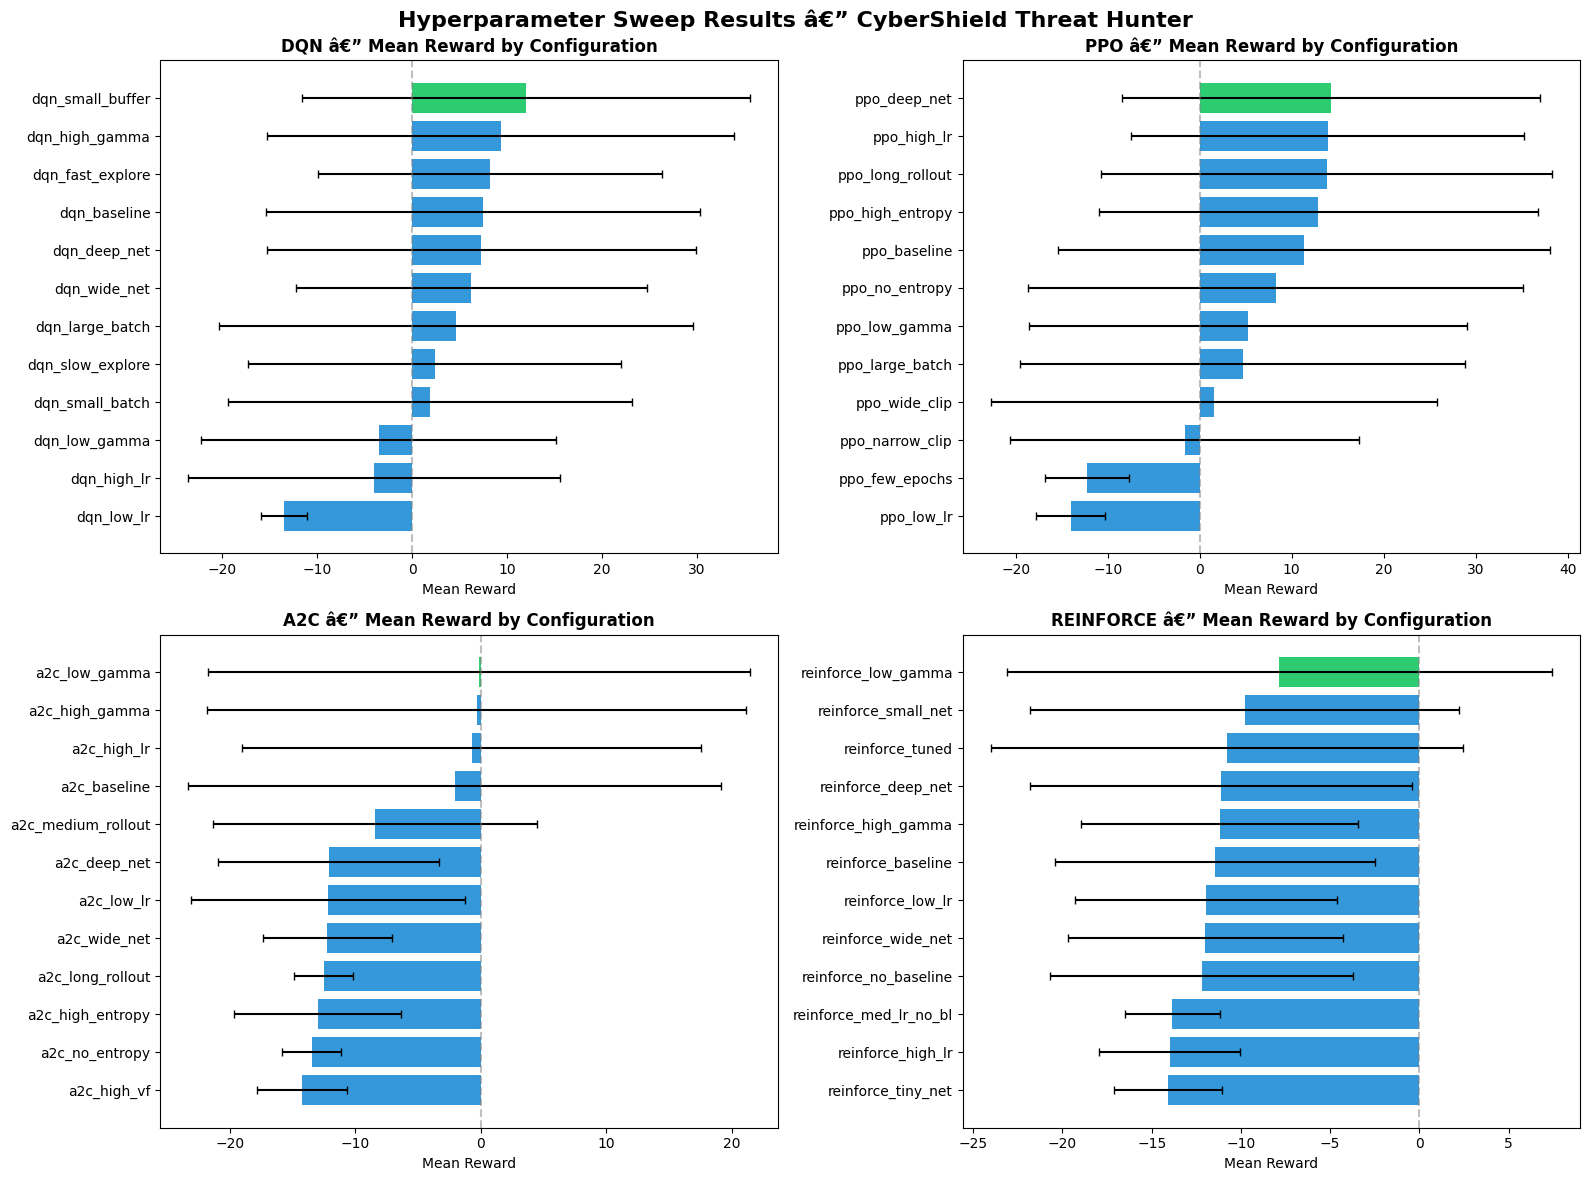

Saved to results/hyperparameter_comparison.png


In [ ]:
# Bar chart: Best reward per algorithm
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hyperparameter Sweep Results â€” CyberShield Threat Hunter', fontsize=16, fontweight='bold')

for ax, (name, df) in zip(axes.flatten(),
    [('DQN', dqn_df), ('PPO', ppo_df), ('A2C', a2c_df), ('REINFORCE', reinforce_df)]):
    df_sorted = df.sort_values('mean_reward', ascending=True)
    colors = ['#2ecc71' if r == df_sorted['mean_reward'].max() else '#3498db'
              for r in df_sorted['mean_reward']]
    ax.barh(df_sorted['name'], df_sorted['mean_reward'],
            xerr=df_sorted['std_reward'], color=colors, capsize=3)
    ax.set_title(f'{name} â€” Mean Reward by Configuration', fontweight='bold')
    ax.set_xlabel('Mean Reward')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('results/hyperparameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/hyperparameter_comparison.png")

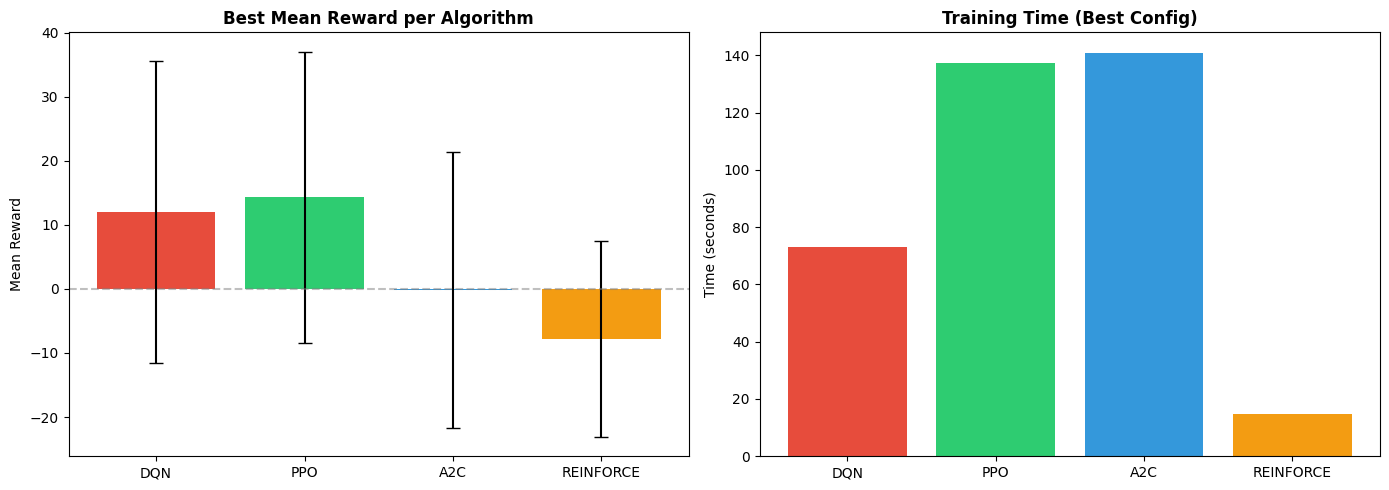


Best Results:
Algorithm         Best Config  Mean Reward  Std Reward  Training Time (s)
      DQN    dqn_small_buffer       11.975   23.543829          73.096043
      PPO        ppo_deep_net       14.300   22.737854         137.244345
      A2C       a2c_low_gamma       -0.175   21.583718         140.967511
REINFORCE reinforce_low_gamma       -7.850   15.271788          14.876637


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cross-algorithm comparison: best of each
best_results = []
for name, df in [('DQN', dqn_df), ('PPO', ppo_df), ('A2C', a2c_df), ('REINFORCE', reinforce_df)]:
    best = df.loc[df['mean_reward'].idxmax()]
    best_results.append({
        'Algorithm': name,
        'Best Config': best['name'],
        'Mean Reward': best['mean_reward'],
        'Std Reward': best['std_reward'],
        'Training Time (s)': best['training_time_s'],
    })

best_df = pd.DataFrame(best_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
ax1.bar(best_df['Algorithm'], best_df['Mean Reward'],
        yerr=best_df['Std Reward'], color=colors, capsize=5)
ax1.set_title('Best Mean Reward per Algorithm', fontweight='bold')
ax1.set_ylabel('Mean Reward')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax2.bar(best_df['Algorithm'], best_df['Training Time (s)'], color=colors)
ax2.set_title('Training Time (Best Config)', fontweight='bold')
ax2.set_ylabel('Time (seconds)')

plt.tight_layout()
plt.savefig('results/algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBest Results:")
print(best_df.to_string(index=False))
best_df.to_csv('results/best_per_algorithm.csv', index=False)

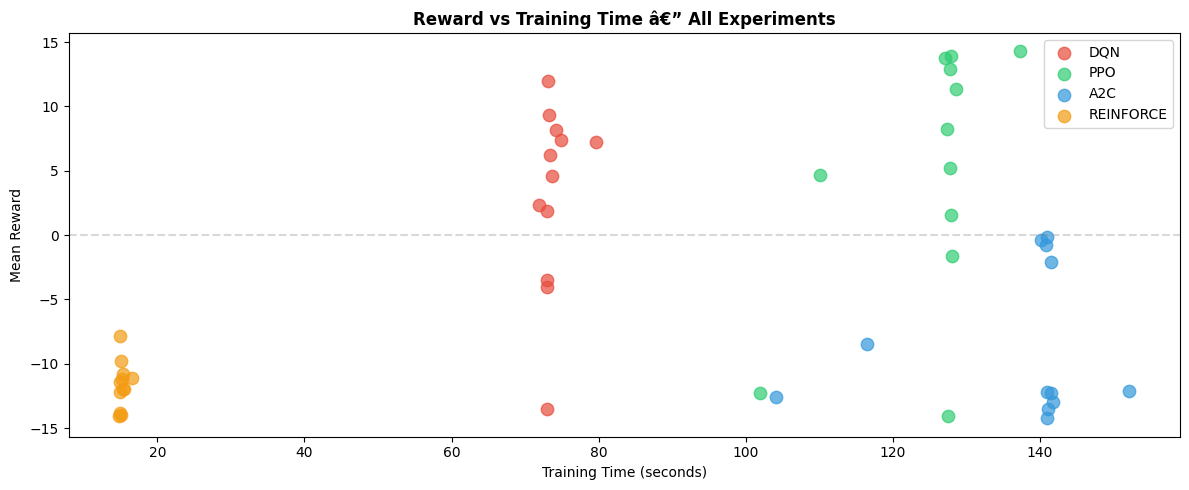

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Training time comparison across all experiments
fig, ax = plt.subplots(figsize=(12, 5))

all_dfs = []
for name, df in [('DQN', dqn_df), ('PPO', ppo_df), ('A2C', a2c_df), ('REINFORCE', reinforce_df)]:
    temp = df[['name', 'mean_reward', 'training_time_s']].copy()
    temp['algorithm'] = name
    all_dfs.append(temp)

all_df = pd.concat(all_dfs)
for algo, color in zip(['DQN', 'PPO', 'A2C', 'REINFORCE'], colors):
    subset = all_df[all_df['algorithm'] == algo]
    ax.scatter(subset['training_time_s'], subset['mean_reward'],
              label=algo, color=color, s=80, alpha=0.7)

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Mean Reward')
ax.set_title('Reward vs Training Time â€” All Experiments', fontweight='bold')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('results/reward_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Models to Google Drive

In [ ]:
# Zip everything and copy to Drive for persistence
import shutil

DRIVE_PATH = '/content/drive/MyDrive/rl_summative_outputs'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Zip models and results
shutil.make_archive('/content/models_backup', 'zip', '.', 'models')
shutil.make_archive('/content/results_backup', 'zip', '.', 'results')

shutil.copy('/content/models_backup.zip', f'{DRIVE_PATH}/models.zip')
shutil.copy('/content/results_backup.zip', f'{DRIVE_PATH}/results.zip')

print(f'Models and results saved to Google Drive: {DRIVE_PATH}')
print('Download these and extract into your local rl_summative/ project.')

Models and results saved to Google Drive: /content/drive/MyDrive/rl_summative_outputs
Download these and extract into your local rl_summative/ project.


In [ ]:
# Alternative: Download directly to your computer
from google.colab import files

# Download models
files.download('/content/models_backup.zip')
files.download('/content/results_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7b. Training Curves (Cumulative Reward, Loss, Entropy)

In [ ]:
import glob as globlib

def load_training_metrics(pattern):
    """Load training_metrics.npz files matching a glob pattern."""
    results = {}
    for path in sorted(globlib.glob(pattern)):
        name = os.path.basename(os.path.dirname(path))
        data = np.load(path, allow_pickle=True)
        results[name] = data
    return results

def smooth(arr, window=20):
    """Simple moving average."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window)/window, mode='valid')

dqn_metrics = load_training_metrics('results/dqn/*/training_metrics.npz')
ppo_metrics = load_training_metrics('results/ppo/*/training_metrics.npz')
a2c_metrics = load_training_metrics('results/a2c/*/training_metrics.npz')
print(f'Loaded: DQN={len(dqn_metrics)}, PPO={len(ppo_metrics)}, A2C={len(a2c_metrics)}')


Loaded: DQN=12, PPO=12, A2C=12


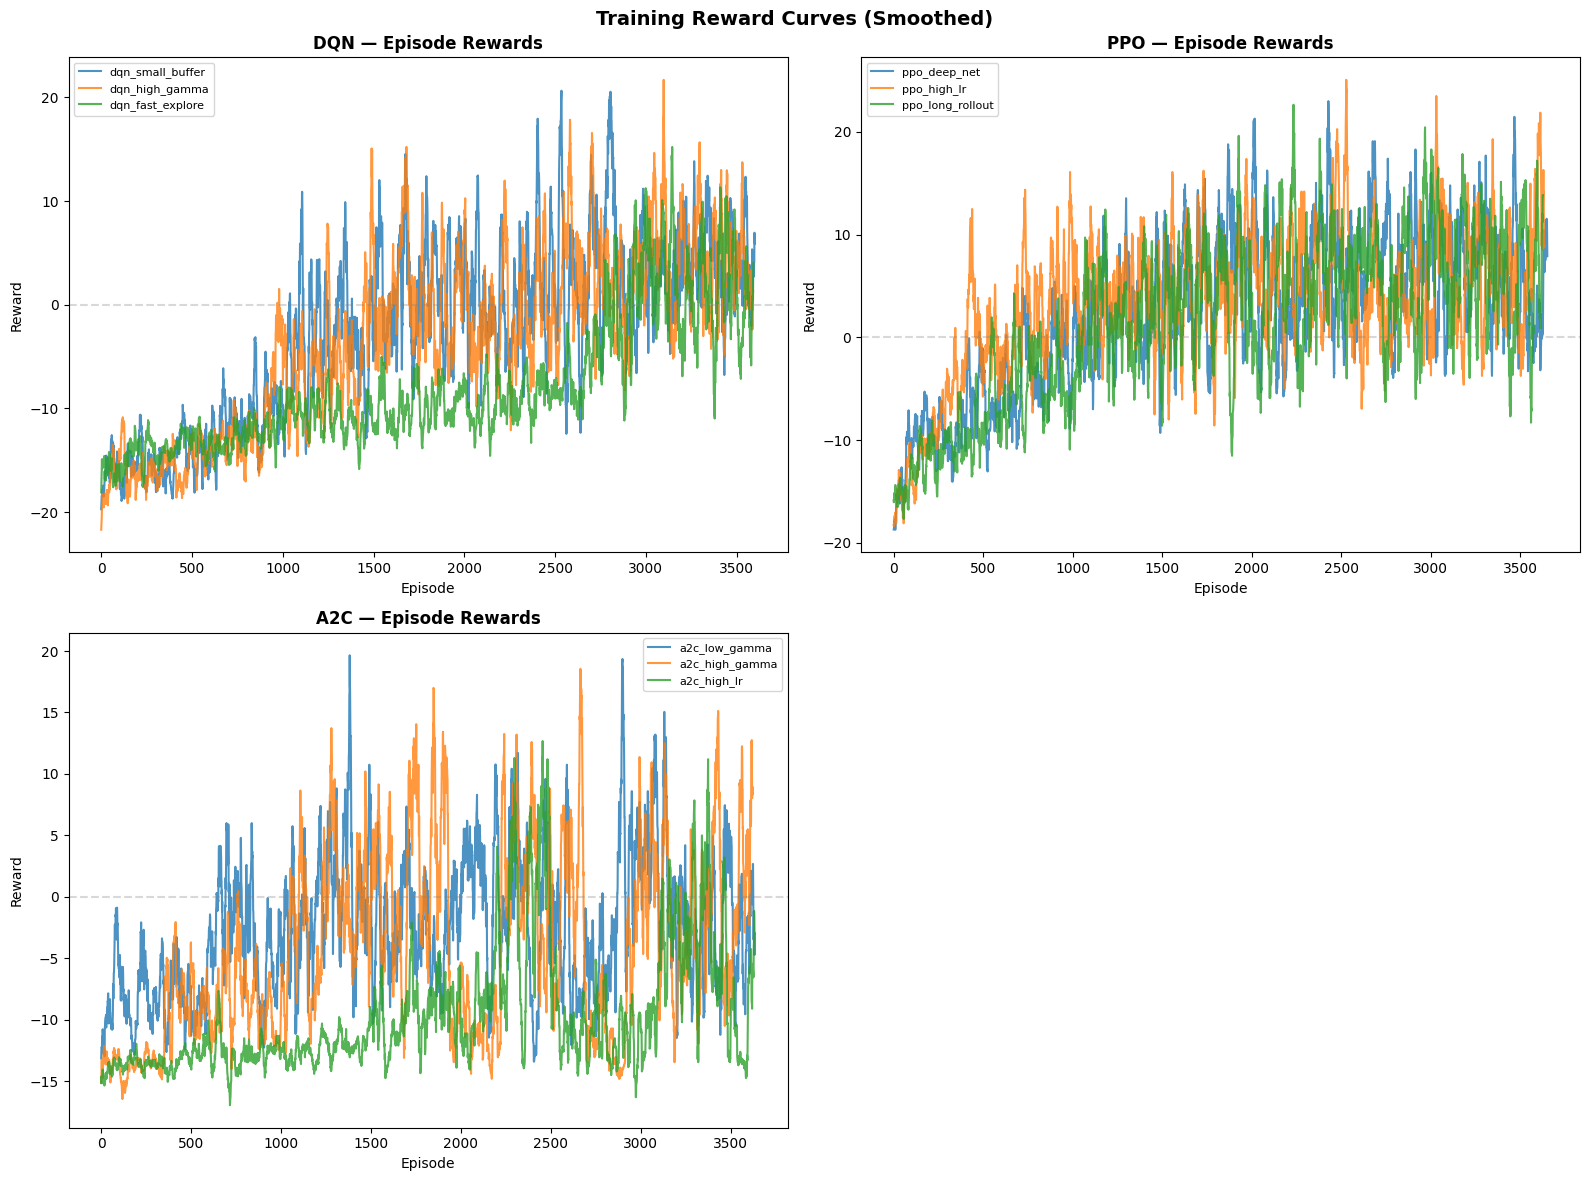

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Cumulative reward curves — best 3 configs per algorithm
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training Reward Curves (Smoothed)', fontsize=14, fontweight='bold')

for ax, (algo, metrics, rdf) in zip(axes.flatten()[:3], [
    ('DQN', dqn_metrics, dqn_df),
    ('PPO', ppo_metrics, ppo_df),
    ('A2C', a2c_metrics, a2c_df),
]):
    top3 = rdf.nlargest(3, 'mean_reward')['name'].tolist()
    for name in top3:
        if name in metrics:
            rewards = metrics[name]['episode_rewards']
            if len(rewards) > 0:
                ax.plot(smooth(rewards), label=name, alpha=0.8)
    ax.set_title(f'{algo} — Episode Rewards', fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

axes.flatten()[3].set_visible(False)
plt.tight_layout()
plt.savefig('results/training_reward_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# DQN loss curves and PG entropy curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DQN Loss & Policy Gradient Entropy Curves', fontsize=14, fontweight='bold')

# DQN Loss
ax = axes[0]
for name in list(dqn_metrics.keys())[:3]:
    losses = dqn_metrics[name]['losses']
    if len(losses) > 0:
        ax.plot(smooth(losses, 50), label=name, alpha=0.8)
ax.set_title('DQN — Training Loss', fontweight='bold')
ax.set_xlabel('Update Step'); ax.set_ylabel('Loss')
ax.legend(fontsize=7)

# PPO Entropy
ax = axes[1]
for name in list(ppo_metrics.keys())[:3]:
    ent = ppo_metrics[name]['entropies']
    if len(ent) > 0:
        ax.plot(smooth(ent, 50), label=name, alpha=0.8)
ax.set_title('PPO — Entropy', fontweight='bold')
ax.set_xlabel('Update Step'); ax.set_ylabel('Entropy')
ax.legend(fontsize=7)

# A2C Entropy
ax = axes[2]
for name in list(a2c_metrics.keys())[:3]:
    ent = a2c_metrics[name]['entropies']
    if len(ent) > 0:
        ax.plot(smooth(ent, 50), label=name, alpha=0.8)
ax.set_title('A2C — Entropy', fontweight='bold')
ax.set_xlabel('Update Step'); ax.set_ylabel('Entropy')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('results/loss_entropy_curves.png', dpi=150, bbox_inches='tight')
plt.show()


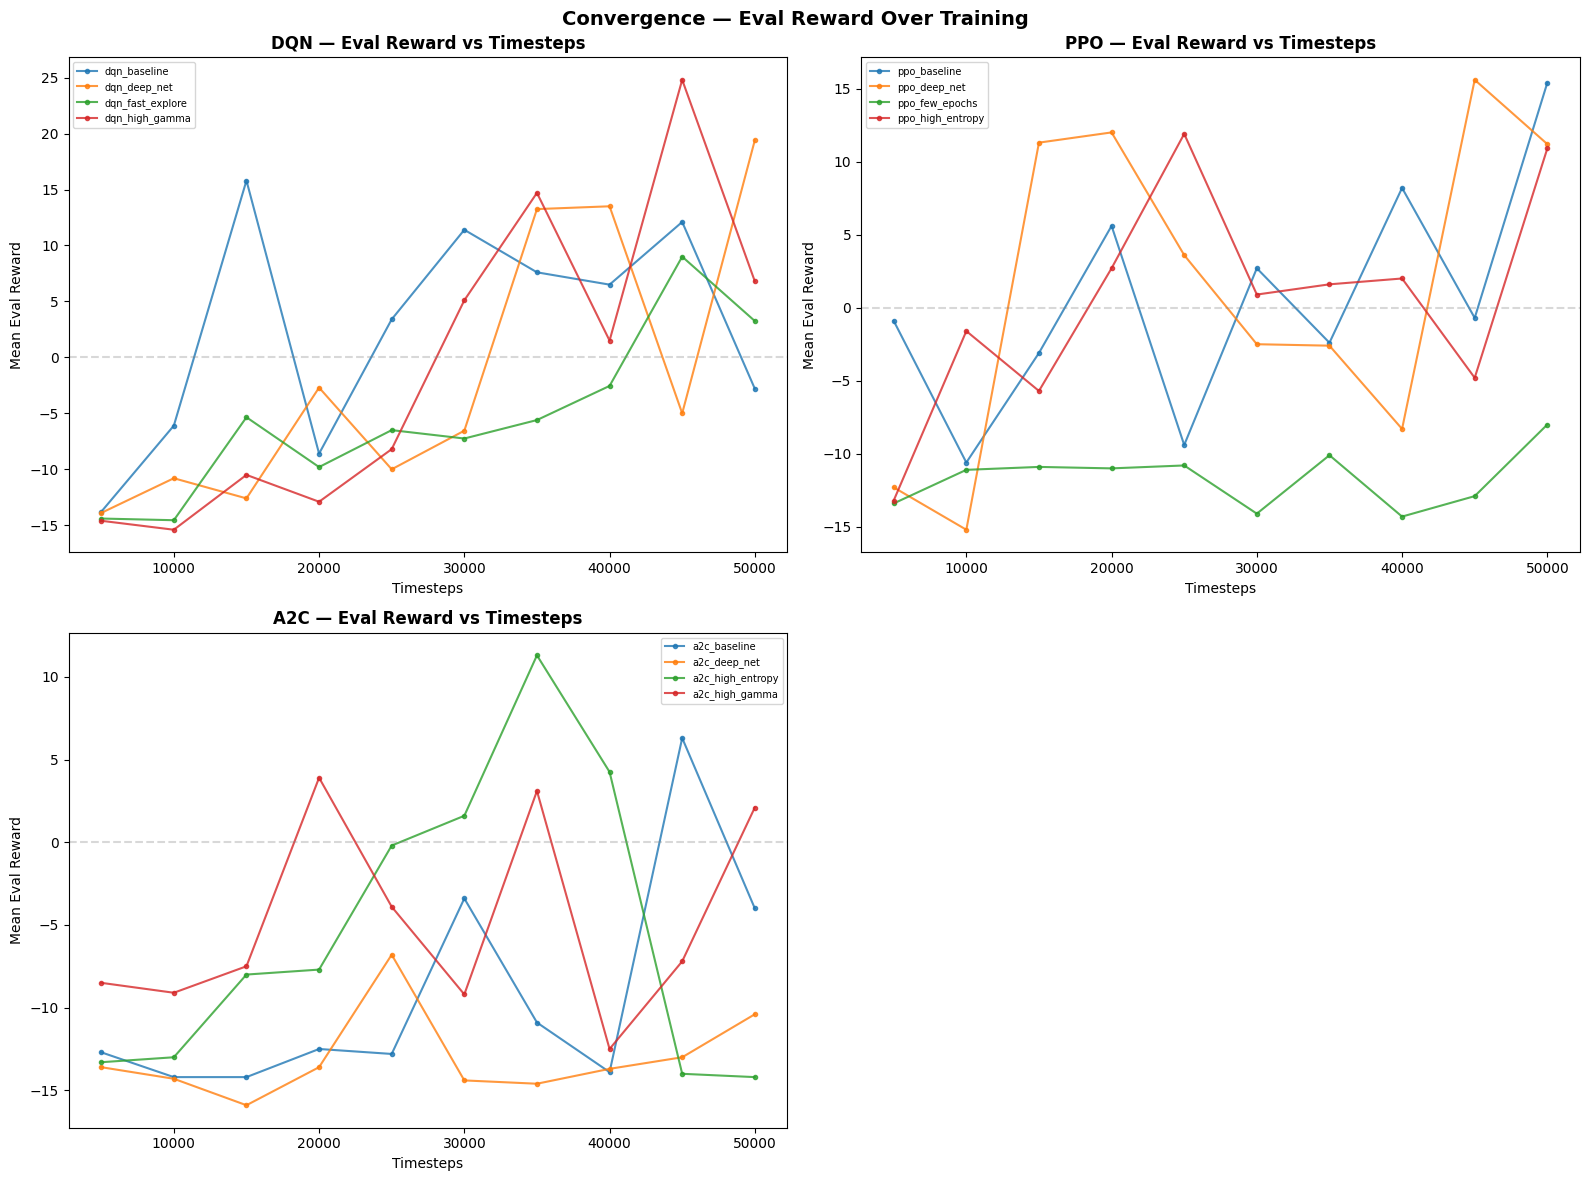

In [ ]:
# Convergence plot: Eval reward over training timesteps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Convergence — Eval Reward Over Training', fontsize=14, fontweight='bold')

eval_patterns = {
    'DQN': 'results/dqn/*/evaluations.npz',
    'PPO': 'results/ppo/*/evaluations.npz',
    'A2C': 'results/a2c/*/evaluations.npz',
}

for ax, (algo, pattern) in zip(axes.flatten()[:3], eval_patterns.items()):
    for fpath in sorted(globlib.glob(pattern))[:4]:
        name = os.path.basename(os.path.dirname(fpath))
        data = np.load(fpath)
        timesteps = data['timesteps']
        mean_rewards = data['results'].mean(axis=1)
        ax.plot(timesteps, mean_rewards, label=name, alpha=0.8, marker='o', markersize=3)
    ax.set_title(f'{algo} — Eval Reward vs Timesteps', fontweight='bold')
    ax.set_xlabel('Timesteps'); ax.set_ylabel('Mean Eval Reward')
    ax.legend(fontsize=7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

axes.flatten()[3].set_visible(False)
plt.tight_layout()
plt.savefig('results/convergence_plots.png', dpi=150, bbox_inches='tight')
plt.show()


## 7c. Generalization Tests

Test the best model from each algorithm on 10 different unseen random seeds.

In [ ]:
import torch
from training.reinforce_training import REINFORCEAgent

TEST_SEEDS = list(range(1000, 1010))  # 10 unseen seeds

def gen_test_sb3(algo_cls, model_path, seeds):
    model = algo_cls.load(model_path)
    rewards = []
    for seed in seeds:
        env = CyberThreatHuntEnv(num_nodes=14, num_threats=4, max_steps=100)
        obs, _ = env.reset(seed=seed)
        total_r, done = 0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(int(action))
            total_r += r; done = term or trunc
        rewards.append(total_r); env.close()
    return rewards

def gen_test_reinforce(model_path, seeds):
    env = CyberThreatHuntEnv(num_nodes=14, num_threats=4, max_steps=100)
    agent = REINFORCEAgent(env.observation_space.shape[0], env.action_space.n)
    agent.load(model_path)
    rewards = []
    for seed in seeds:
        obs, _ = env.reset(seed=seed)
        total_r, done = 0, False
        while not done:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(agent.device)
            action = agent.policy(obs_t).probs.argmax().item()
            obs, r, term, trunc, _ = env.step(action)
            total_r += r; done = term or trunc
        rewards.append(total_r)
    env.close()
    return rewards

gen_results = {}
for algo, cls, pat in [
    ('DQN', DQN, 'models/dqn/*/best_model.zip'),
    ('PPO', PPO, 'models/pg/ppo/*/best_model.zip'),
    ('A2C', A2C, 'models/pg/a2c/*/best_model.zip'),
]:
    paths = sorted(globlib.glob(pat)) or sorted(globlib.glob(pat.replace('best_model', 'final_model')))
    if paths:
        print(f'Testing {algo}: {paths[0]}')
        gen_results[algo] = gen_test_sb3(cls, paths[0], TEST_SEEDS)
        print(f'  {np.mean(gen_results[algo]):.1f} +/- {np.std(gen_results[algo]):.1f}')

rpaths = sorted(globlib.glob('models/pg/reinforce/*/best_model.pt')) or \
         sorted(globlib.glob('models/pg/reinforce/*/final_model.pt'))
if rpaths:
    print(f'Testing REINFORCE: {rpaths[0]}')
    gen_results['REINFORCE'] = gen_test_reinforce(rpaths[0], TEST_SEEDS)
    print(f'  {np.mean(gen_results["REINFORCE"]):.1f} +/- {np.std(gen_results["REINFORCE"]):.1f}')


Testing DQN: models/dqn/dqn_baseline/best_model.zip
  3.0 +/- 20.1
Testing PPO: models/pg/ppo/ppo_baseline/best_model.zip


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force 

  10.0 +/- 19.8
Testing A2C: models/pg/a2c/a2c_baseline/best_model.zip
  5.8 +/- 22.1
Testing REINFORCE: models/pg/reinforce/reinforce_baseline/best_model.pt
  -12.2 +/- 1.7


/tmp/ipykernel_7592/3336405246.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=algos, patch_artist=True, widths=0.5)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


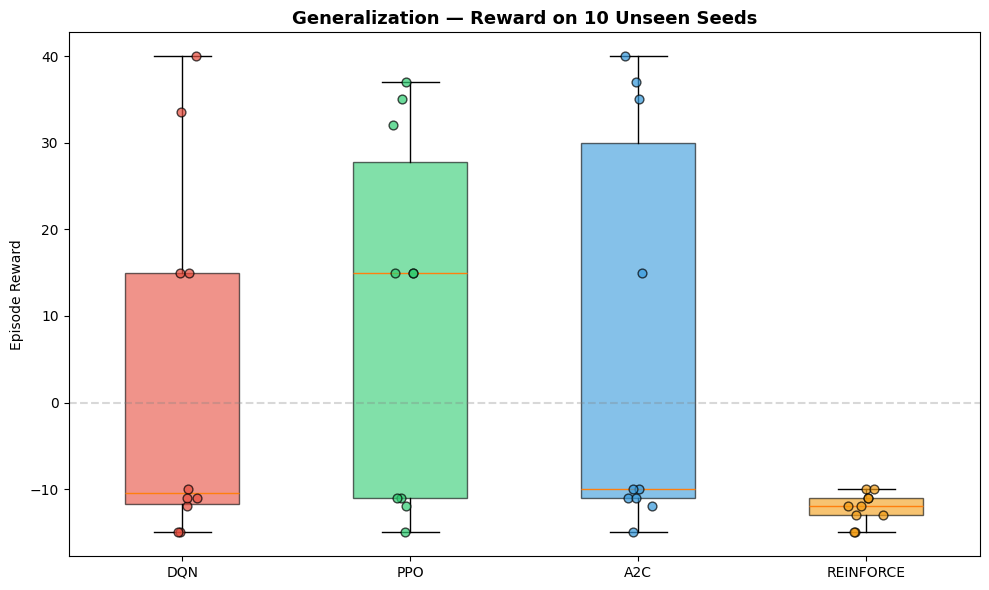


Generalization Results:
         DQN    PPO    A2C  REINFORCE
count  10.00  10.00  10.00      10.00
mean    2.95  10.00   5.80     -12.20
std    21.14  20.83  23.32       1.81
min   -15.00 -15.00 -15.00     -15.00
25%   -11.75 -11.00 -11.00     -13.00
50%   -10.50  15.00 -10.00     -12.00
75%    15.00  27.75  30.00     -11.00
max    40.00  37.00  40.00     -10.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Generalization box plot
fig, ax = plt.subplots(figsize=(10, 6))
algos = list(gen_results.keys())
data = [gen_results[a] for a in algos]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12'][:len(algos)]

bp = ax.boxplot(data, labels=algos, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)

for i, (algo, rewards) in enumerate(gen_results.items()):
    x = np.random.normal(i + 1, 0.04, size=len(rewards))
    ax.scatter(x, rewards, alpha=0.7, color=colors[i], edgecolors='black', s=40, zorder=5)

ax.set_title('Generalization — Reward on 10 Unseen Seeds', fontweight='bold', fontsize=13)
ax.set_ylabel('Episode Reward')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('results/generalization_test.png', dpi=150, bbox_inches='tight')
plt.show()

gen_df = pd.DataFrame({a: pd.Series(r) for a, r in gen_results.items()})
gen_df.to_csv('results/generalization_results.csv', index=False)
print('\nGeneralization Results:')
print(gen_df.describe().round(2))


## 10. Export Complete Project as Single Zip

In [ ]:
import shutil
import os

EXPORT_DIR = "/content/rl_summative_export"
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)
os.makedirs(EXPORT_DIR)

# Copy all project files into export folder
for folder in ["environment", "training", "models", "results"]:
    src = os.path.join(os.getcwd(), folder)
    dst = os.path.join(EXPORT_DIR, folder)
    if os.path.exists(src):
        shutil.copytree(src, dst)
        print(f"  Copied {folder}/")

for f in ["main.py", "requirements.txt", "README.md"]:
    src = os.path.join(os.getcwd(), f)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(EXPORT_DIR, f))
        print(f"  Copied {f}/")

# Create the zip
shutil.make_archive("/content/rl_summative_complete", "zip", "/content", "rl_summative_export")
zip_size = os.path.getsize("/content/rl_summative_complete.zip") / (1024 * 1024)
print(f"""
Export ready: rl_summative_complete.zip ({zip_size:.1f} MB)
""")
# Save to Drive
DRIVE_PATH = "/content/drive/MyDrive/rl_summative_outputs"
os.makedirs(DRIVE_PATH, exist_ok=True)
shutil.copy("/content/rl_summative_complete.zip", f"{DRIVE_PATH}/rl_summative_complete.zip")
print(f"Saved to Drive: {DRIVE_PATH}/rl_summative_complete.zip")

# Download to local machine
from google.colab import files
files.download("/content/rl_summative_complete.zip")

  Copied environment/
  Copied training/
  Copied models/
  Copied results/

Export ready: rl_summative_complete.zip (69.0 MB)

Saved to Drive: /content/drive/MyDrive/rl_summative_outputs/rl_summative_complete.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>